# How to deal with imbalanced datasets?

- CODE: feat: [SC] - reduce the impact of financial phrasebank imbalance [#95](https://github.com/ufdatastudio/predictions/issues/95)

---
1. ARTICLE: [Should You Use Imbalanced-Learn in 2025?](https://www.blog.trainindata.com/should-you-use-imbalanced-learn-in-2025/)
2. PAPER: [Imbalanced-learn: A Python Toolbox to Tackle the Curse of Imbalanced Datasets in Machine Learning](https://www.jmlr.org/papers/v18/16-365.html)

In [1]:
import os
import sys

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt


from sklearn.datasets import make_classification
from imblearn.over_sampling import RandomOverSampler

# Get the current working directory of the notebook
notebook_dir = os.getcwd()
# Add the parent directory to the system path
sys.path.append(os.path.join(notebook_dir, '../'))

from data_processing import DataProcessing
from data_visualizing import DataVisualizing
from feature_extraction import SpacyFeatureExtraction

## Experiment with Synthetic data

- Comes from [1]

## Step 1: Create a synthetic imbalanced dataset

In [2]:
X, y = make_classification(
n_samples=500,
n_features=2,
n_informative=2,
n_redundant=0,
n_clusters_per_class=1,
weights=[0.9, 0.1],
flip_y=0,
random_state=42
)

In [3]:
# Correct approach
synthetic_df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
synthetic_df['Label'] = y
synthetic_df

,Feature_1,Feature_2,Label
0,-0.634459,1.196683,0
1,1.059371,0.121880,0
2,-0.346128,0.670353,0
3,-4.058955,2.498408,0
4,-1.495259,2.865142,0
...,...,...,...
495,-1.450271,0.630604,0
496,2.026043,2.720493,1
497,-0.890525,0.469038,0
498,-3.293571,1.747423,0


## Step 2: Visualize the original dataset before oversampling

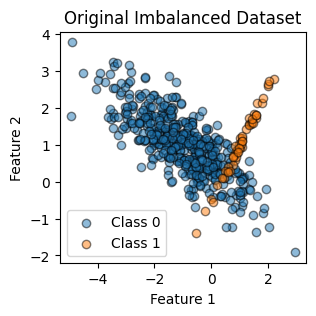

In [4]:
plt.figure(figsize=(7, 3))
plt.subplot(1, 2, 1)
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label="Class 0", alpha=0.5, edgecolor="k")
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label="Class 1", alpha=0.5, edgecolor="k")
plt.title("Original Imbalanced Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()

## Step 3: Apply RandomOverSampler to balance the dataset

In [5]:
oversample = RandomOverSampler(sampling_strategy='minority', random_state=42)
oversample

RandomOverSampler(random_state=42, sampling_strategy='minority')

## Step 4: Visualize the dataset after oversampling

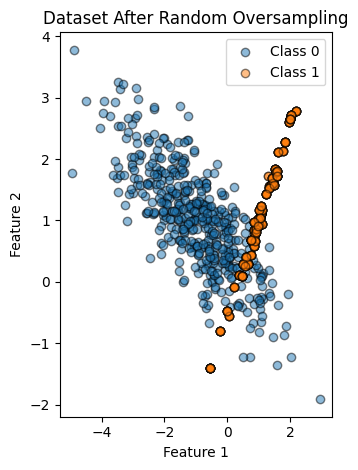

In [6]:
X_over, y_over = oversample.fit_resample(X, y)

plt.subplot(1, 2, 2)
plt.scatter(X_over[y_over == 0][:, 0], X_over[y_over == 0][:, 1], label="Class 0", alpha=0.5, edgecolor="k")
plt.scatter(X_over[y_over == 1][:, 0], X_over[y_over == 1][:, 1], label="Class 1", alpha=0.5, edgecolor="k")
plt.title("Dataset After Random Oversampling")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
X_over

array([[-0.63445852,  1.19668341],
       [ 1.05937142,  0.12188007],
       [-0.34612842,  0.67035266],
       ...,
       [ 2.00426606,  2.64487839],
       [ 0.00438936, -0.47129556],
       [ 0.75582398,  0.67616306]])

In [8]:
# Create separate dataframe for oversampled data
synthetic_oversampled_df = pd.DataFrame(X_over, columns=['Feature_1', 'Feature_2'])
synthetic_oversampled_df['Label'] = y_over
synthetic_oversampled_df

,Feature_1,Feature_2,Label
0,-0.634459,1.196683,0
1,1.059371,0.121880,0
2,-0.346128,0.670353,0
3,-4.058955,2.498408,0
4,-1.495259,2.865142,0
...,...,...,...
895,1.626426,2.121845,1
896,0.965146,0.903895,1
897,2.004266,2.644878,1
898,0.004389,-0.471296,1


In [9]:
print(f"Original: {len(synthetic_df)} rows")
print(f"Oversampled: {len(X_over)} rows")

Original: 500 rows
Oversampled: 900 rows


## Experiment with Financial Phrasebank

## Step 1: Load dataset

In [10]:
base_data_path = DataProcessing.load_base_data_path(notebook_dir)
combine_data_path = os.path.join(base_data_path, 'financial_phrase_bank/annotators')
data_path = os.path.join(combine_data_path, 'maya_annotations-fpb-binary_labels-v2.csv')
df = DataProcessing.load_from_file(path=data_path, file_type='csv', sep = ",", encoding = 'latin')
df.dropna(inplace=True)
df

,Base Sentence,maya_label,Sentence Label,Author Type
0,With the new production plant the company woul...,PREDICTION,1,1
1,According to the company 's updated strategy f...,PREDICTION,1,1
2,TeliaSonera TLSN said the offer is in line wit...,PREDICTION,1,1
3,"STORA ENSO , NORSKE SKOG , M-REAL , UPM-KYMMEN...",PREDICTION,1,1
4,The company also estimates the already carried...,PREDICTION,1,1
...,...,...,...,...
4841,LONDON MarketWatch -- Share prices ended lower...,NON-PREDICTION,0,1
4842,Rinkuskiai 's beer sales fell by 6.5 per cent ...,NON-PREDICTION,0,1
4843,Operating profit fell to EUR 35.4 mn from EUR ...,NON-PREDICTION,0,1
4844,Net sales of the Paper segment decreased to EU...,NON-PREDICTION,0,1


## Step 2: Embed Sentences

In [11]:
spacy_fe = SpacyFeatureExtraction(df, 'Base Sentence')
spacy_sentence_embeddings_df = spacy_fe.sentence_embeddings_extraction(attach_to_df=True)
spacy_sentence_embeddings_df

100%|██████████| 4846/4846 [00:19<00:00, 252.62it/s]


,Base Sentence,maya_label,Sentence Label,Author Type,Base Sentence Embedding
0,With the new production plant the company woul...,PREDICTION,1,1,"[-0.12256822, 0.24862413, -0.048265517, -0.109..."
1,According to the company 's updated strategy f...,PREDICTION,1,1,"[-0.26332003, 0.32854047, 0.04485582, -0.01094..."
2,TeliaSonera TLSN said the offer is in line wit...,PREDICTION,1,1,"[0.01150803, 0.19822516, 0.019506244, -0.05977..."
3,"STORA ENSO , NORSKE SKOG , M-REAL , UPM-KYMMEN...",PREDICTION,1,1,"[-0.005943053, 0.15729912, -0.101663664, -0.04..."
4,The company also estimates the already carried...,PREDICTION,1,1,"[-0.09756714, 0.21774293, -0.052489348, 0.0229..."
...,...,...,...,...,...
4841,LONDON MarketWatch -- Share prices ended lower...,NON-PREDICTION,0,1,"[-0.099730656, 0.1643495, 0.017135162, 0.07131..."
4842,Rinkuskiai 's beer sales fell by 6.5 per cent ...,NON-PREDICTION,0,1,"[-0.19892499, 0.30014804, 0.10139055, -0.12584..."
4843,Operating profit fell to EUR 35.4 mn from EUR ...,NON-PREDICTION,0,1,"[-0.12662552, 0.28139418, 0.14707643, -0.08270..."
4844,Net sales of the Paper segment decreased to EU...,NON-PREDICTION,0,1,"[-0.13203417, 0.22406398, 0.031153306, 0.01043..."


## Step 3: Resample + Plot Original vs Resampled + Save Resampled Datasets

In [12]:
base_data_path = DataProcessing.load_base_data_path(notebook_dir)
save_data_path = os.path.join(base_data_path, 'financial_phrase_bank/resampling_maya')

Using file number: 1
Saving CSV file to: /Users/detraviousjamaribrinkley/Documents/Development/research_labs/uf_ds/predictions/notebook_experiments/../data/financial_phrase_bank/resampling_maya/fpb-maya-binary-oversampled-96d-v1.csv
Using file number: 1
Saving CSV file to: /Users/detraviousjamaribrinkley/Documents/Development/research_labs/uf_ds/predictions/notebook_experiments/../data/financial_phrase_bank/resampling_maya/fpb-maya-binary-undersampled-96d-v1.csv


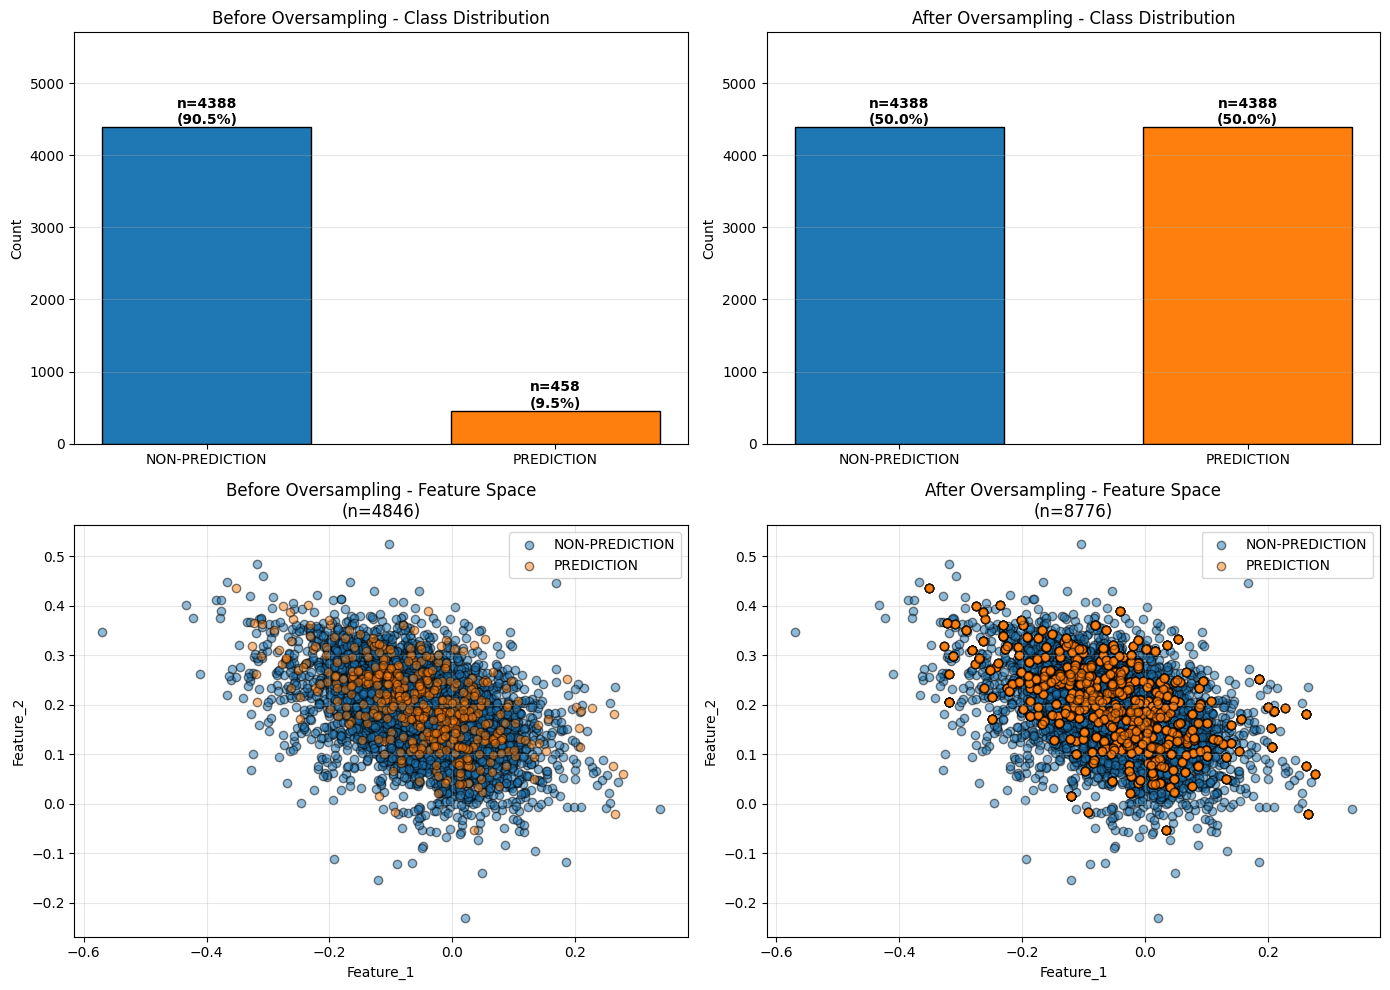

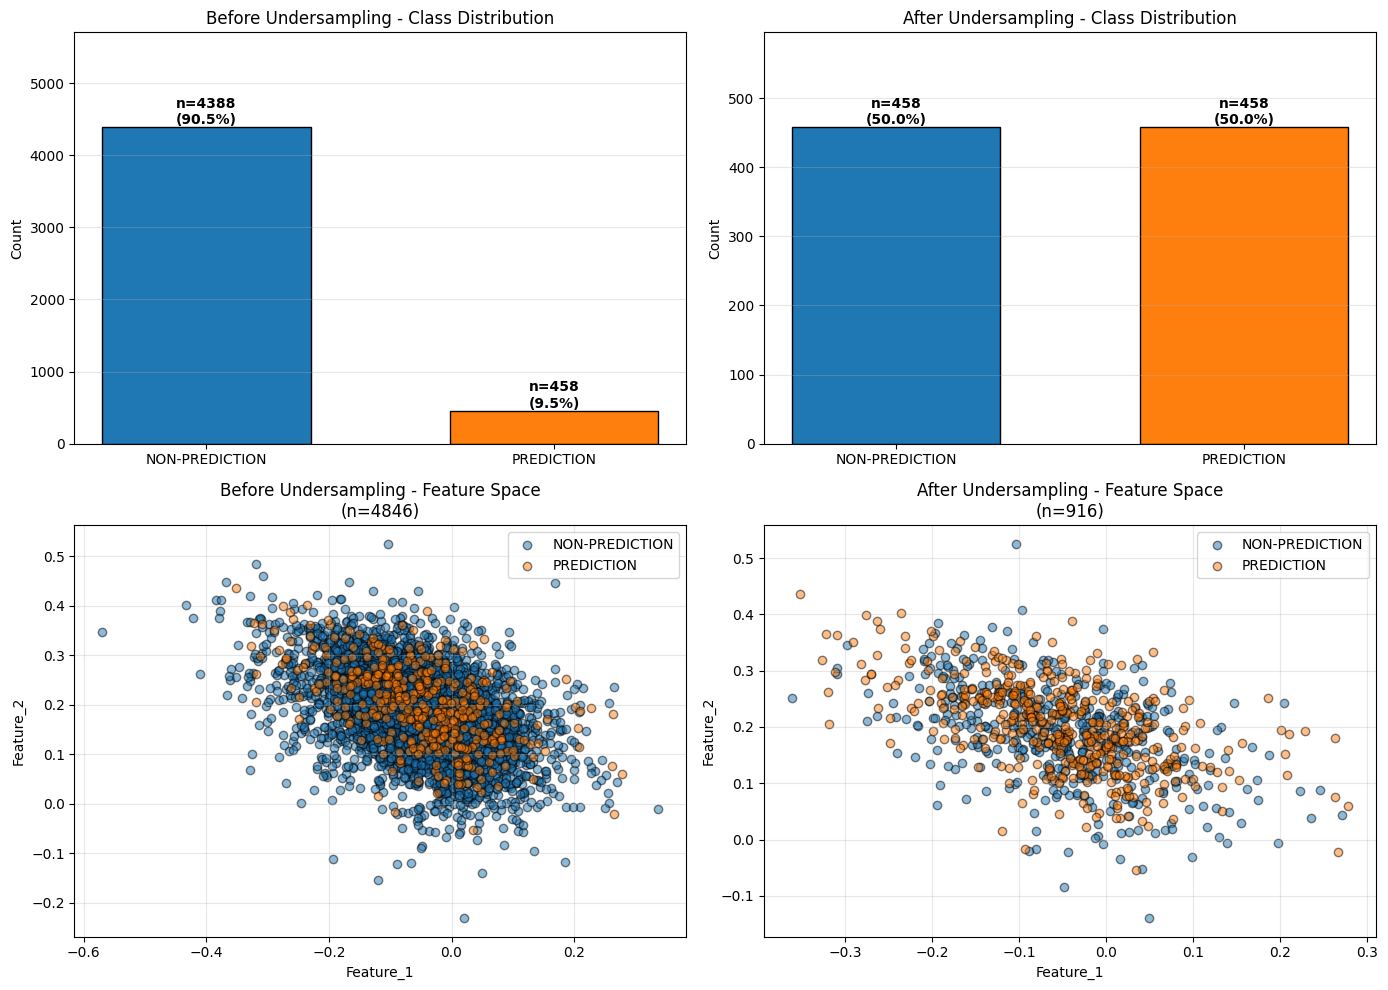

In [15]:
oversampled_96d_df = DataProcessing.apply_resampling_full_dimensions(
    df=df,
    embedding_col='Base Sentence Embedding',
    label_col='Sentence Label',
    method='oversample',
    save_path=save_data_path,
    save_prefix='fpb-maya-binary-oversampled-96d'
)

undersampled_96d_df = DataProcessing.apply_resampling_full_dimensions(
    df=df,
    embedding_col='Base Sentence Embedding',
    label_col='Sentence Label',
    method='undersample',
    save_path=save_data_path,
    save_prefix='fpb-maya-binary-undersampled-96d'
)

# Extract 2D for visualization only
original_2d_df = DataProcessing.extract_features_for_visualization(df, 'Base Sentence Embedding', 'Sentence Label')
over_to_resampled_2d_df = DataProcessing.extract_features_for_visualization(oversampled_96d_df, 'Base Sentence Embedding', 'Sentence Label')
under_to_resampled_2d_df = DataProcessing.extract_features_for_visualization(undersampled_96d_df, 'Base Sentence Embedding', 'Sentence Label')

# Visualize
DataVisualizing.visualize_before_after_resampling(original_2d_df, over_to_resampled_2d_df, class_names=['NON-PREDICTION', 'PREDICTION'], method_name='Oversampling')
DataVisualizing.visualize_before_after_resampling(original_2d_df, under_to_resampled_2d_df, class_names=['NON-PREDICTION', 'PREDICTION'], method_name='Undersampling')

### Ensuring data saving

In [18]:
base_data_path = DataProcessing.load_base_data_path(notebook_dir)
combine_data_path = os.path.join(base_data_path, 'financial_phrase_bank/resampling_maya')
data_path = os.path.join(combine_data_path, 'fpb-maya-binary-undersampled-96d-v1.csv')
df = DataProcessing.load_from_file(path=data_path, file_type='csv', sep = ",", encoding = 'latin')
# df.dropna(inplace=True)
df

,Base Sentence,maya_label,Sentence Label,Author Type,Base Sentence Embedding
0,Seventy-three of those also have more extensiv...,NON-PREDICTION,0,1,[-2.56694425e-02 7.73361996e-02 -2.97912043e-...
1,"The transaction covers a building lot of 46,76...",NON-PREDICTION,0,1,[ 1.87365919e-01 1.50340468e-01 -1.82901602e-...
2,Her present position is the director of Stockm...,NON-PREDICTION,0,1,[ 8.05021599e-02 1.41935304e-01 5.96351698e-...
3,The third order awarded to Outokumpu Technolog...,NON-PREDICTION,0,1,[-5.27474247e-02 1.48081347e-01 2.86115818e-...
4,Earnings per share for the quarter were also h...,NON-PREDICTION,0,1,[-2.09101573e-01 3.17221403e-01 -3.86219248e-...
...,...,...,...,...,...
911,The company 's previous estimate was for a low...,PREDICTION,1,1,[-1.12862647e-01 2.79943228e-01 -1.65856872e-...
912,Finnish Suominen Corporation that makes wipes ...,PREDICTION,1,1,[-7.12546930e-02 1.91423342e-01 -9.48487520e-...
913,The net sales of the whole fiscal year 2008 wi...,PREDICTION,1,1,[-2.15959132e-01 2.41876766e-01 2.61752661e-...
914,Operating profit excluding non-recurring items...,PREDICTION,1,1,[-2.70101726e-01 2.94426471e-01 2.46293880e-...


- > `prediction_classification_experiments-v2/main-ml.py` to train ML models and previously used `prediction_classification_experiments-v2/ml_classifiers.ipynb`
- > `prediction_classification_experiments/average_classification_results.py` to average

- > If want to train multiple runs and average results once, run: cd bash_scripts/ and run `bash train_ml_models.sh`. Terminal commands:
- > 1. python3 main-ml-v2.py --dataset ../data/financial_phrase_bank/resampling_maya/fpb-maya-binary-oversampled-96d-v1.csv --seed $seed
- > 2. python3 main-ml-v2.py --dataset ../data/financial_phrase_bank/resampling_maya/fpb-maya-binary-undersampled-96d-v1.csv --seed $seed